# 3. Label Smoothing进阶（2）

## 3.0 上节内容回顾与本节主要内容介绍

在前两节中，我们学习并实现了Label Smoothing分类损失，并用实验验证了使用Label Smoothing训练网络能够提升模型的鲁棒性。

在本节中，我们将继续关于Label Smoothing的实验与研究。本实验的主要内容为采用PyTorch等技术，训练使用不同平滑系数的Label Smoothing模型，并分别测试其鲁棒性，通过对比获得鲁棒性最好的Label Smoothing模型。

## 3.1 导入相关模块

In [4]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import importlib.util
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import logging

import test; test_fn = test.test
from loss import LabelSmoothingCrossEntropyLoss, CWLoss
from pgd import LinfPGD
from utils import load_mnist_test
from models import LeNet5


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

## 3.2 模型训练与测试

我们的目标是编写一个函数能够实现特定平滑系数的模型训练和鲁棒性测试。

In [5]:
def ls_train_eval(ls_lambda):
    """ 设置训练参数 """
    EPOCH = 50              # 训练总epoch数
    BATCH_SIZE = 256        # 训练batch size大小
    LR = 0.001              # 初始学习率
    DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）
    LS_LAMBDA = ls_lambda   # Label Smoothing参数

    # 检查数据集路径是否存在以及数据集是否存在
    if not(os.path.exists('./data/')) or not os.listdir('./data/'):
        DOWNLOAD_MNIST = True

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    """ 导入数据，定义数据接口 """
    train_dataset = torchvision.datasets.MNIST(
        root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
    test_dataset = torchvision.datasets.MNIST(
        root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    cnn = LeNet5().to(device)

    """ 使用Adam Optimizer """
    optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

    """ 设置Label Smoothing超参数 """
    loss_function = LabelSmoothingCrossEntropyLoss(label_smoothing=LS_LAMBDA)

    """ 训练 """
    train_accs = []
    train_losses = []
    test_accs = []
    test_losses = []

    for epoch in range(EPOCH):
        cnn.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = cnn(inputs)

            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            pred = outputs.max(dim=1).indices        
            train_total += n
            train_correct += (pred == labels).sum().item()
            train_loss += loss.data.item() * n
            
        train_accs.append(train_correct / train_total)
        train_losses.append(train_loss / train_total)
        
        # 测试
        cnn.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for batch_idx, (inputs, labels) in enumerate(test_loader):
                n = labels.size(0)

                inputs, labels = inputs.to(device), labels.to(device)
                outputs = cnn(inputs)
                loss = loss_function(outputs, labels)
                

                pred = outputs.max(dim=1).indices  
                test_correct += (pred == labels).sum().item()
                test_total += n
                test_loss += loss.data.item() * n

        test_accs.append(test_correct / test_total)
        test_losses.append(test_loss / test_total)

    """ 为了简化输出，在此处不再打印训练过程的准确率与损失，而是用绘图的方式展示 """
    plt.figure(figsize=(15, 5))

    idx = [_ for _ in range(EPOCH)]
    plt.subplot(1, 2, 1)
    plt.plot(idx, train_accs, label='training')
    plt.plot(idx, test_accs, label='test')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(idx, train_losses, label='training')
    plt.plot(idx, test_losses, label='test')
    plt.legend()
    plt.title('Loss')

    plt.suptitle(f'Label Smoothing {LS_LAMBDA}')
    plt.show()
    
    """ 保存模型 """
    state = {
        'net': cnn.state_dict(),
        'num_epoch': epoch,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
    }

    result_path = f'./save_model/' + str(EPOCH) + 'epoch'
    if not os.path.isdir(result_path):
        os.makedirs(result_path)
    torch.save(state, result_path + f'/mnist_lenet5_ls{LS_LAMBDA}.pth')

    """ 鲁棒性测试 """
    cnn.eval()

    # 定义攻击参数
    FGSM_kwargs = dict(net=cnn, eps=0.1, step=1, step_size=0.1, random_start=False)
    PGD_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True)
    CW_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

    # 创建攻击
    FGSM = LinfPGD(**FGSM_kwargs)
    PGD = LinfPGD(**PGD_kwargs)
    CW = LinfPGD(**CW_kwargs)

    # 加载样本
    imgs, lbls = load_mnist_test()
    
    # 执行测试
    cln_acc, _ = test_fn(cnn, imgs, lbls, bs=250, mode='clean')                         # 干净样本
    fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')  # FGSM
    pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')    # PGD
    cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')      # CW

    logger.info(f'LS {LS_LAMBDA}  Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}')
    
    return [cln_acc, fgsm_acc, pgd_acc, cw_acc]

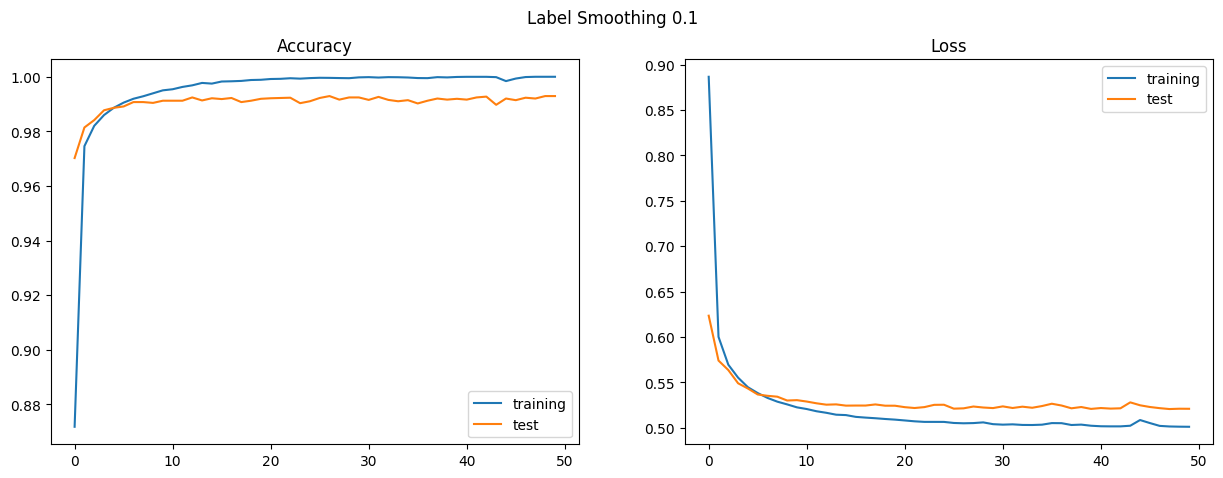

 27040 20260201 18:48:18 LS 0.1  Clean: 99.29, FGSM: 92.03, PGD: 69.83, CW: 61.49


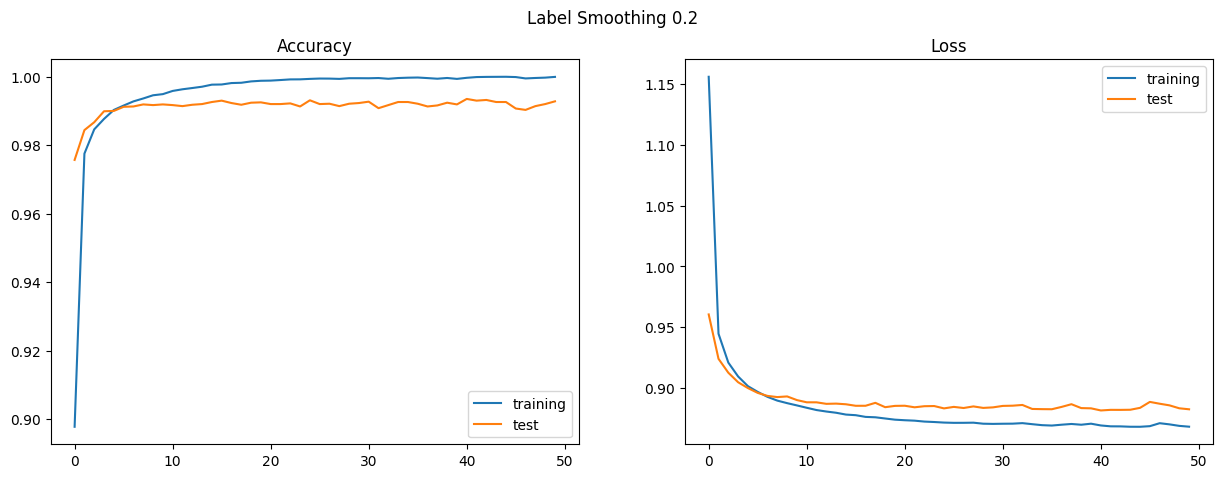

 27040 20260201 18:57:02 LS 0.2  Clean: 99.28, FGSM: 94.00, PGD: 81.26, CW: 74.55


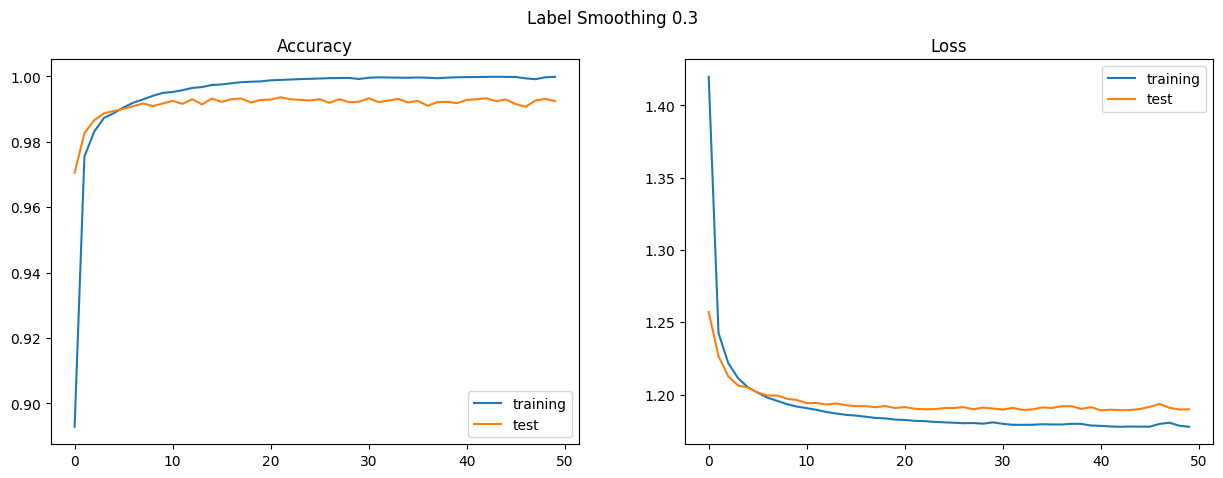

 27040 20260201 19:05:43 LS 0.3  Clean: 99.24, FGSM: 90.37, PGD: 68.10, CW: 62.64


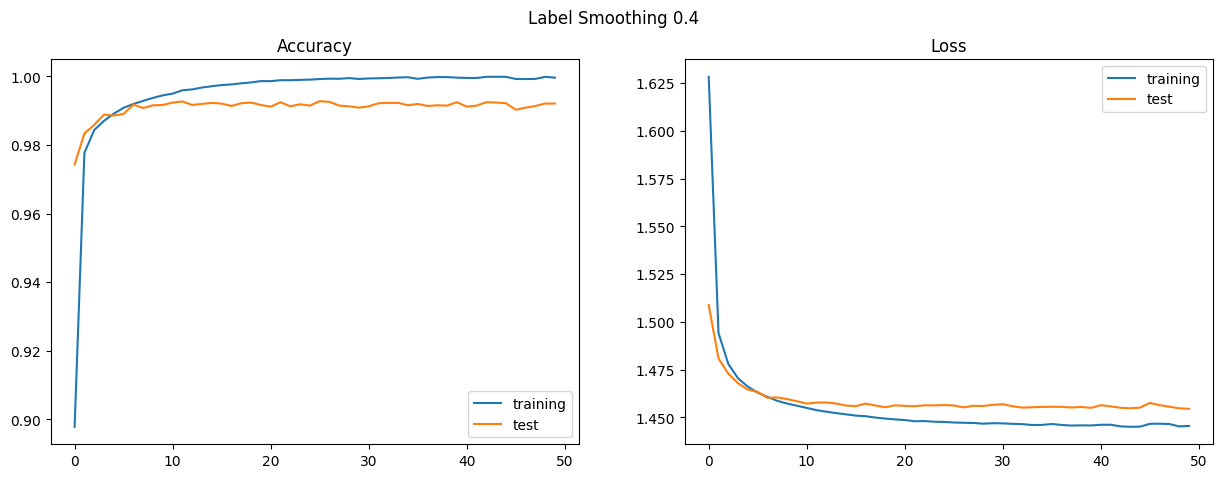

 27040 20260201 19:14:25 LS 0.4  Clean: 99.21, FGSM: 94.69, PGD: 83.35, CW: 71.42


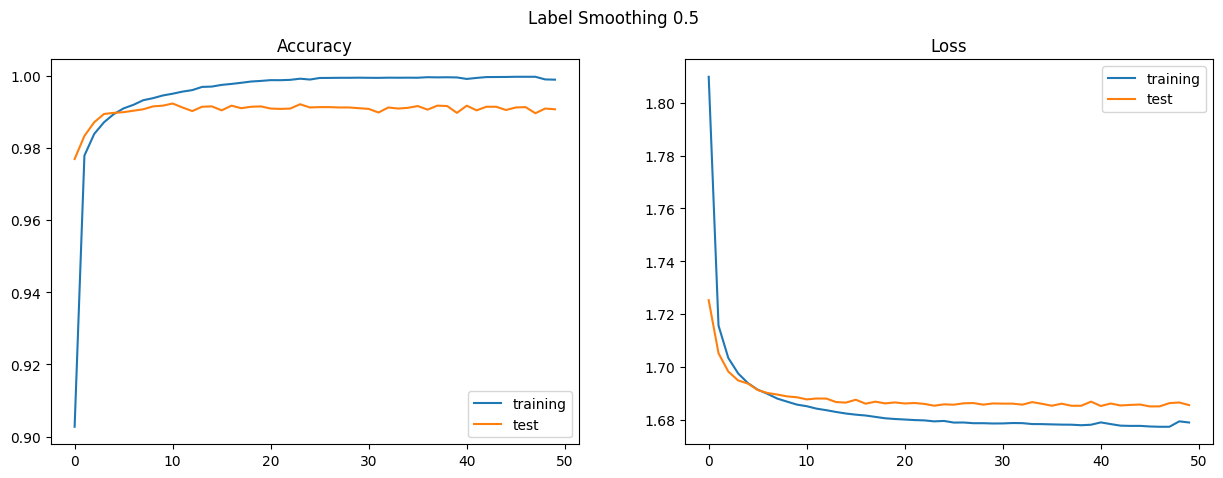

 27040 20260201 19:23:10 LS 0.5  Clean: 99.08, FGSM: 92.65, PGD: 78.05, CW: 71.33


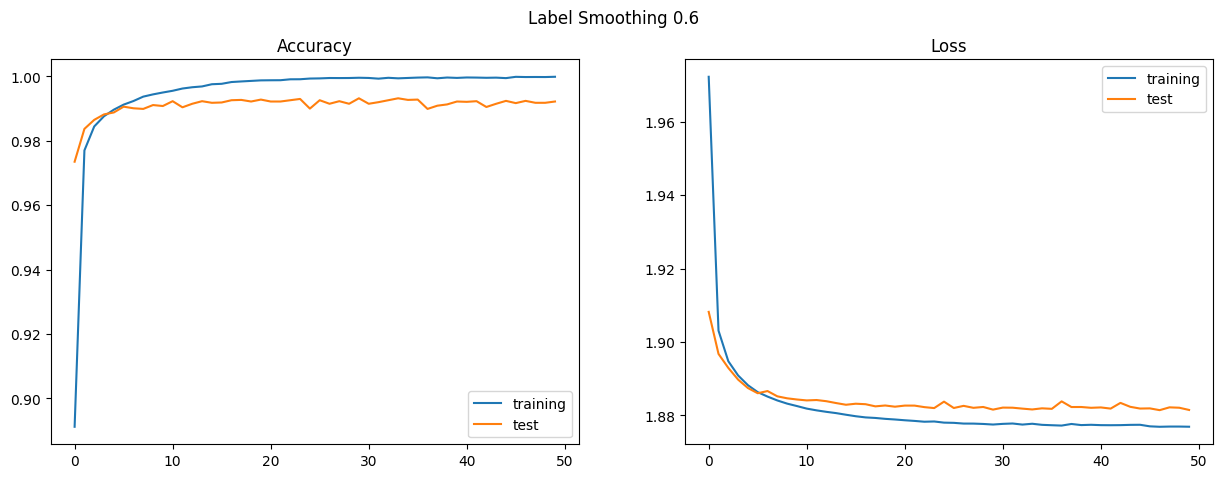

 27040 20260201 19:32:22 LS 0.6  Clean: 99.22, FGSM: 94.80, PGD: 86.95, CW: 78.85


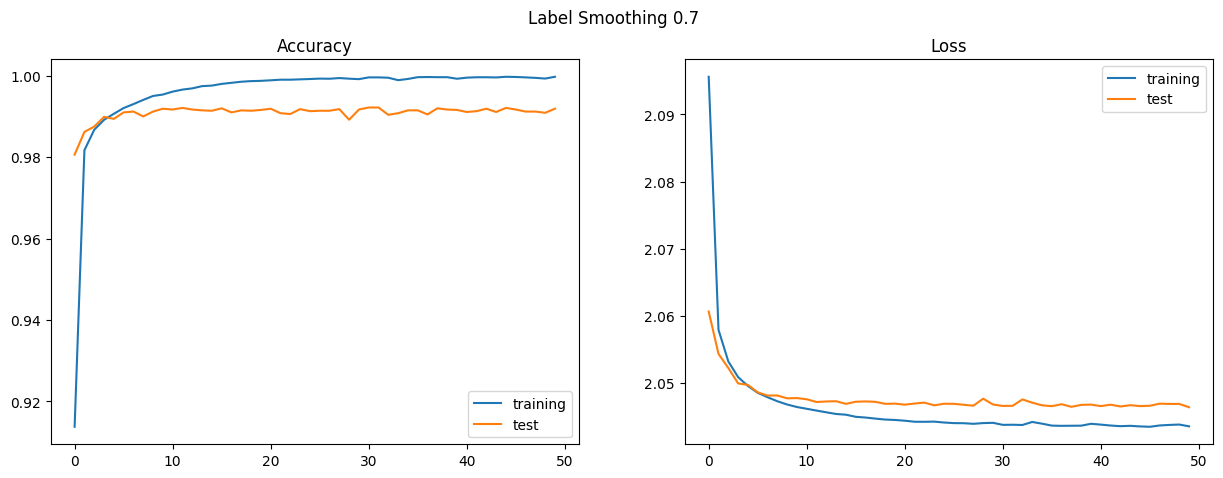

 27040 20260201 19:40:33 LS 0.7  Clean: 99.19, FGSM: 95.29, PGD: 87.99, CW: 82.62


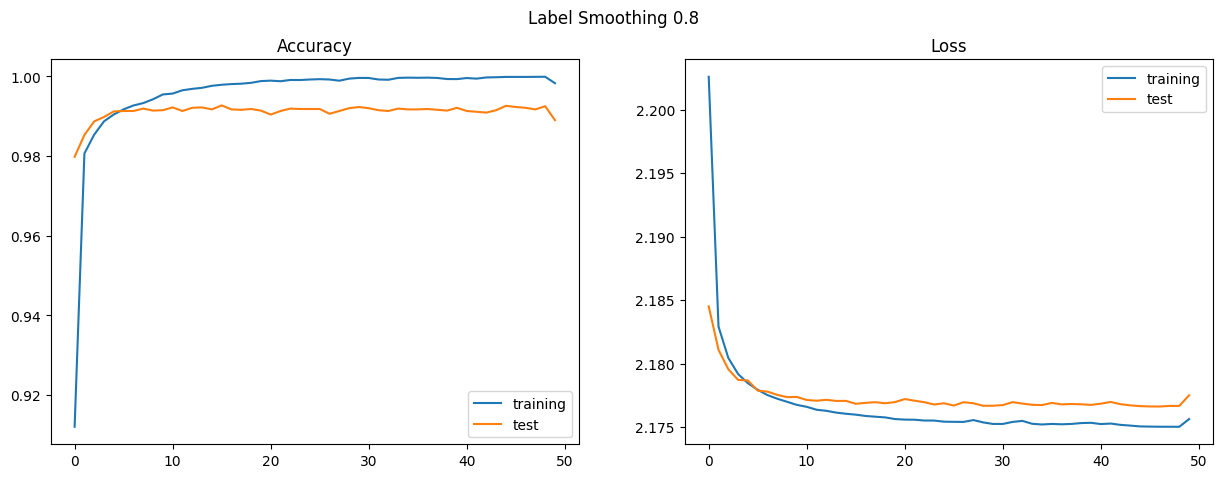

 27040 20260201 19:49:34 LS 0.8  Clean: 98.90, FGSM: 91.90, PGD: 75.27, CW: 72.44


In [3]:
"""
    测试不同平滑系数Label Smoothing防御性能，其中ls=0,ls=0.9已经在
上个实验“1. 对抗性防御算法之Label Smoothing”中完成了。
"""
LS_LAMBDA_LIST = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]  # 
result_dict = {}

for LS_LAMBDA in LS_LAMBDA_LIST:
    result_dict[LS_LAMBDA] = ls_train_eval(LS_LAMBDA)

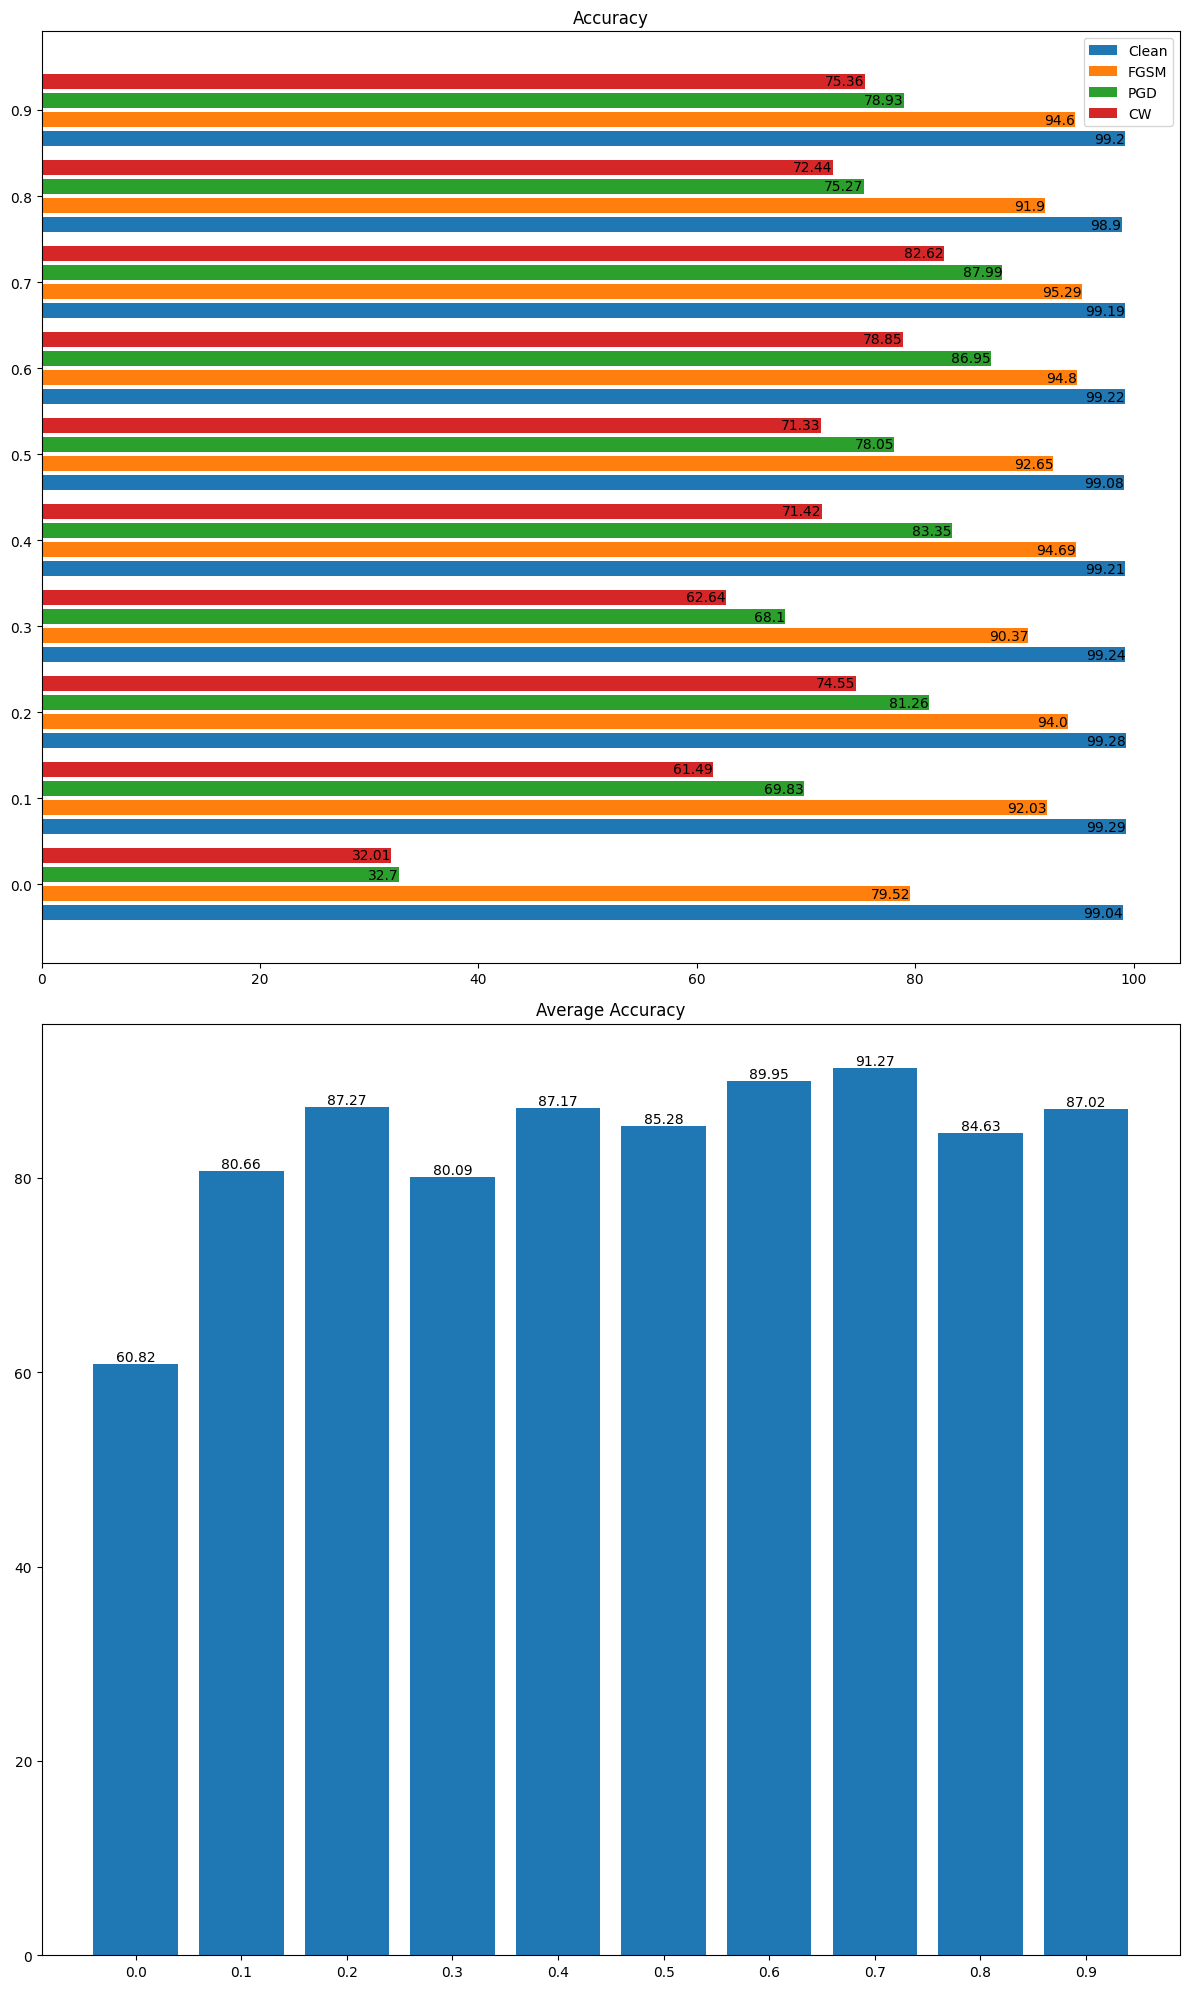

In [4]:
import numpy as np

# “1. 对抗性防御算法之Label Smoothing”实验的结果
result_dict[0.0] = [99.04, 79.52, 32.70, 32.01]
result_dict[0.9] = [99.20, 94.60, 78.93, 75.36]

ls_lambda_list = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
idx = 4.5 * np.arange(len(ls_lambda_list))
item_list = ['Clean', 'FGSM', 'PGD', 'CW']

# 绘制条形图，对比不同Label Smoothing参数训练的模型的性能
plt.figure(figsize=(12, 20))

plt.subplot(2, 1, 1)
for i, item in enumerate(item_list):
    acc_list = [result_dict[k][i] for k in ls_lambda_list]
    plt.barh(idx + i, acc_list, label=item)

    for j, acc in zip(idx, acc_list):
        plt.text(acc, j + i, acc, ha='right', va='center')

plt.legend()
plt.yticks(idx + 1.5, ls_lambda_list)
plt.title('Accuracy')

plt.subplot(2, 1, 2)
idx = np.arange(len(ls_lambda_list))
mean_acc_list = [sum(result_dict[k]) / len(result_dict[k]) for k in ls_lambda_list]
plt.bar(idx, mean_acc_list)
for i, acc in enumerate(mean_acc_list):
    plt.text(i, acc, f'{acc:.2f}', ha='center', va='bottom')
plt.xticks(idx, ls_lambda_list)
plt.title('Average Accuracy')
plt.tight_layout()
plt.show()

可以看出使用label smoothing进行训练，不同的平滑系数相较于标准训练均有提升。其中，以平滑系数为0.7训练得出的LeNet5模型效果最好。

___请大家自己实现用Label Smoothing策略训练FCNet，尝试不同平滑系数，并选出鲁棒性最好的模型。___

## 3.3 使用Label Smoothing策略训练FCNet并选出鲁棒性最好的模型

FCNet是一个三层全连接网络（784→300→100→10），我们将使用与LeNet5相同的实验流程，
分别以不同的平滑系数训练FCNet，并测试其在Clean、FGSM、PGD、CW攻击下的鲁棒性，最终选出鲁棒性最好的模型。

In [11]:
from models import FCNet

def fcnet_ls_train_eval(ls_lambda):
    """ 设置训练参数 """
    EPOCH = 50              # 训练总epoch数
    BATCH_SIZE = 256        # 训练batch size大小
    LR = 0.001              # 初始学习率
    DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）
    LS_LAMBDA = ls_lambda   # Label Smoothing参数

    # 检查数据集路径是否存在以及数据集是否存在
    if not(os.path.exists('./data/')) or not os.listdir('./data/'):
        DOWNLOAD_MNIST = True

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    """ 导入数据，定义数据接口 """
    train_dataset = torchvision.datasets.MNIST(
        root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
    test_dataset = torchvision.datasets.MNIST(
        root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    """ 定义FCNet网络结构 """
    fcnet = FCNet().to(device)

    """ 使用Adam Optimizer """
    optimizer = torch.optim.Adam(fcnet.parameters(), lr=LR)

    """ 设置Label Smoothing超参数 """
    loss_function = LabelSmoothingCrossEntropyLoss(label_smoothing=LS_LAMBDA)

    num_params = sum(p.numel() for p in fcnet.parameters() if p.requires_grad)
    logger.info(f'FCNet 模型参数大小为：{num_params}')

    """ 训练 """
    train_accs = []
    train_losses = []
    test_accs = []
    test_losses = []

    for epoch in range(EPOCH):
        fcnet.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = fcnet(inputs)

            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            pred = outputs.max(dim=1).indices
            train_total += n
            train_correct += (pred == labels).sum().item()
            train_loss += loss.data.item() * n

        train_accs.append(train_correct / train_total)
        train_losses.append(train_loss / train_total)

        # 测试
        fcnet.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for batch_idx, (inputs, labels) in enumerate(test_loader):
                n = labels.size(0)

                inputs, labels = inputs.to(device), labels.to(device)
                outputs = fcnet(inputs)
                loss = loss_function(outputs, labels)

                pred = outputs.max(dim=1).indices
                test_correct += (pred == labels).sum().item()
                test_total += n
                test_loss += loss.data.item() * n

        test_accs.append(test_correct / test_total)
        test_losses.append(test_loss / test_total)

    """ 为了简化输出，在此处不再打印训练过程的准确率与损失，而是用绘图的方式展示 """
    plt.figure(figsize=(15, 5))

    idx = [_ for _ in range(EPOCH)]
    plt.subplot(1, 2, 1)
    plt.plot(idx, train_accs, label='training')
    plt.plot(idx, test_accs, label='test')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(idx, train_losses, label='training')
    plt.plot(idx, test_losses, label='test')
    plt.legend()
    plt.title('Loss')

    plt.suptitle(f'FCNet Label Smoothing {LS_LAMBDA}')
    plt.show()

    """ 保存模型 """
    state = {
        'net': fcnet.state_dict(),
        'num_epoch': epoch,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
    }

    result_path = os.path.join(r'D:\软件\对抗性防御\对抗性防御-1\03.代码\save_model', str(EPOCH) + 'epoch')
    if not os.path.isdir(result_path):
        os.makedirs(result_path)
    save_file = os.path.join(result_path, f'mnist_fcnet_ls{LS_LAMBDA}.pth')
    torch.save(state, save_file, _use_new_zipfile_serialization=False)

    """ 鲁棒性测试 """
    fcnet.eval()

    # 定义攻击参数
    FGSM_kwargs = dict(net=fcnet, eps=0.1, step=1, step_size=0.1, random_start=False)
    PGD_kwargs = dict(net=fcnet, eps=0.1, step=20, step_size=0.025, random_start=True)
    CW_kwargs = dict(net=fcnet, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

    # 创建攻击
    FGSM = LinfPGD(**FGSM_kwargs)
    PGD = LinfPGD(**PGD_kwargs)
    CW = LinfPGD(**CW_kwargs)

    # 加载样本
    imgs, lbls = load_mnist_test()

    # 执行测试
    cln_acc, _ = test_fn(fcnet, imgs, lbls, bs=250, mode='clean')                         # 干净样本
    fgsm_acc, _ = test_fn(nn.Sequential(FGSM, fcnet), imgs, lbls, bs=250, mode='attack')  # FGSM
    pgd_acc, _ = test_fn(nn.Sequential(PGD, fcnet), imgs, lbls, bs=250, mode='attack')    # PGD
    cw_acc, _ = test_fn(nn.Sequential(CW, fcnet), imgs, lbls, bs=250, mode='attack')      # CW

    logger.info(f'FCNet LS {LS_LAMBDA}  Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}')

    return [cln_acc, fgsm_acc, pgd_acc, cw_acc]

 20612 20260207 01:56:51 FCNet 模型参数大小为：266610


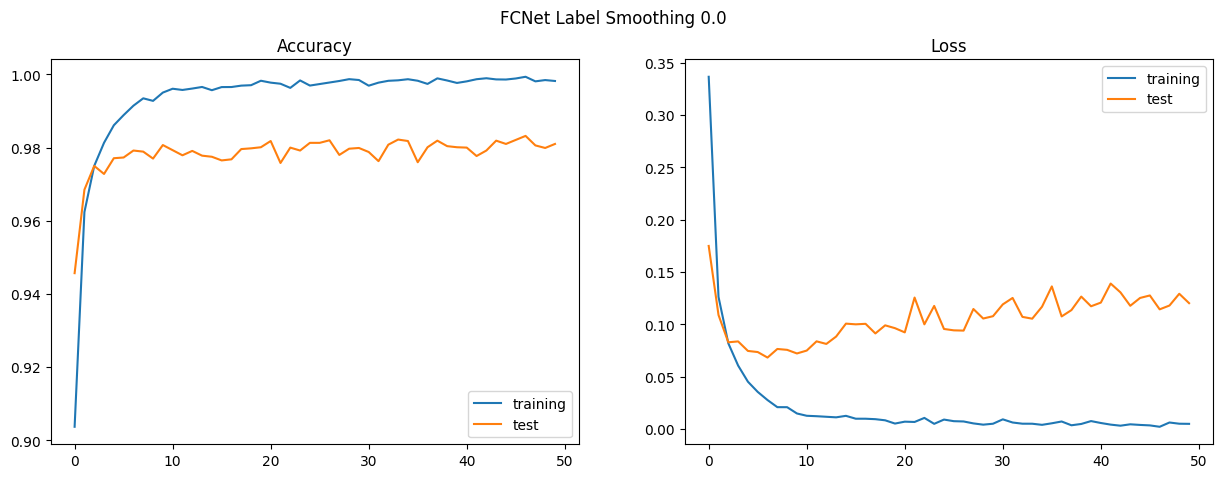

 20612 20260207 02:05:08 FCNet LS 0.0  Clean: 98.10, FGSM: 54.37, PGD: 21.78, CW: 20.93
 20612 20260207 02:05:08 FCNet 模型参数大小为：266610


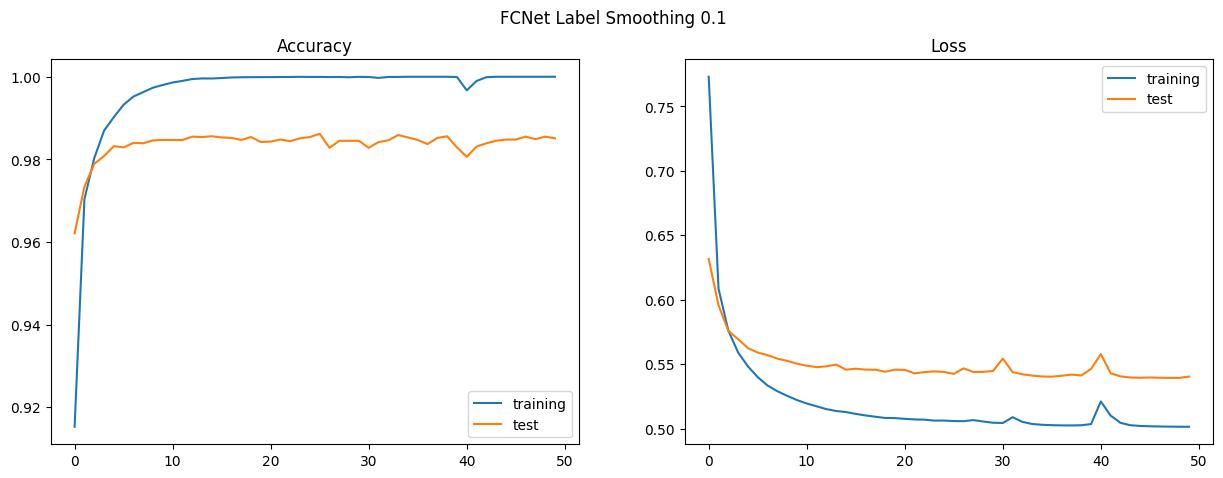

 20612 20260207 02:13:21 FCNet LS 0.1  Clean: 98.51, FGSM: 71.62, PGD: 33.80, CW: 28.69
 20612 20260207 02:13:21 FCNet 模型参数大小为：266610


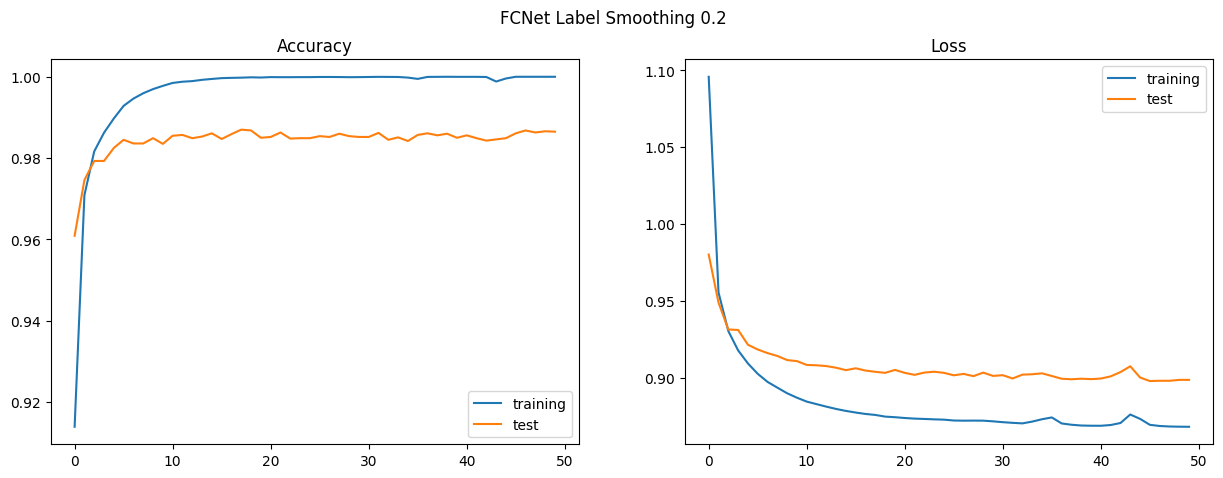

 20612 20260207 02:21:45 FCNet LS 0.2  Clean: 98.65, FGSM: 69.84, PGD: 29.05, CW: 22.02
 20612 20260207 02:21:45 FCNet 模型参数大小为：266610


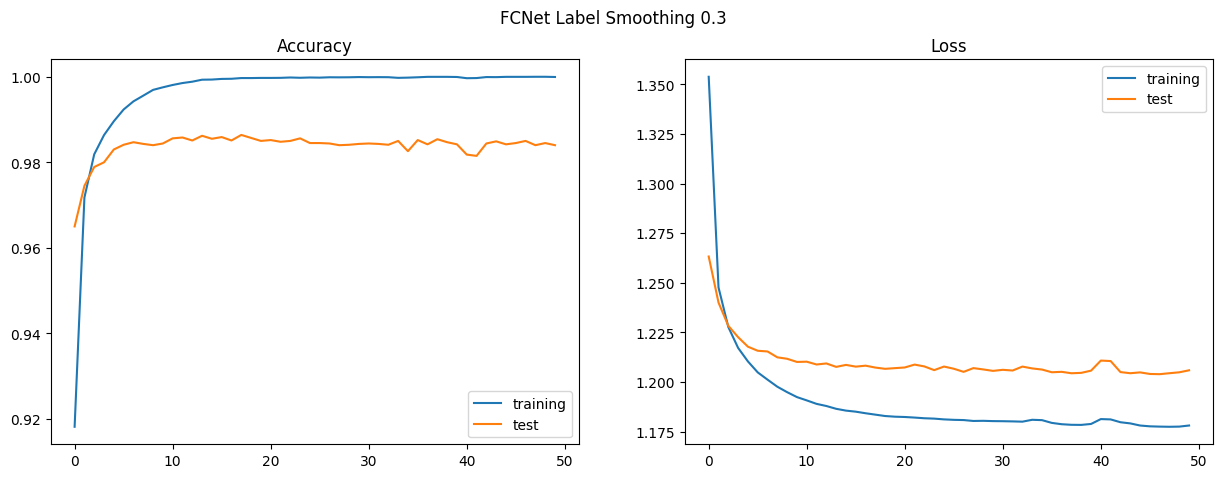

 20612 20260207 02:30:09 FCNet LS 0.3  Clean: 98.40, FGSM: 72.49, PGD: 36.21, CW: 26.79
 20612 20260207 02:30:09 FCNet 模型参数大小为：266610


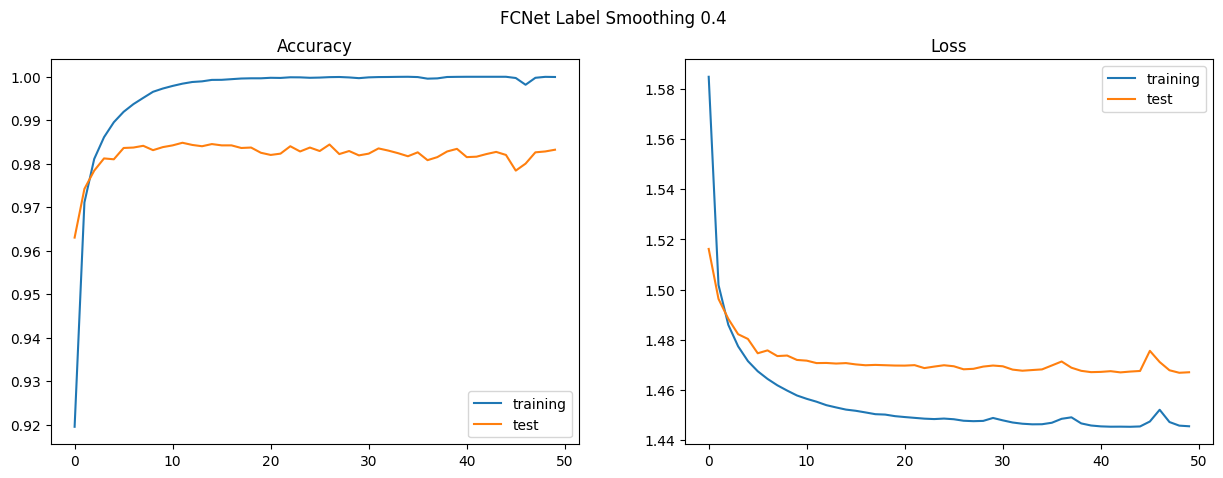

 20612 20260207 02:38:25 FCNet LS 0.4  Clean: 98.32, FGSM: 72.47, PGD: 32.70, CW: 24.31
 20612 20260207 02:38:25 FCNet 模型参数大小为：266610


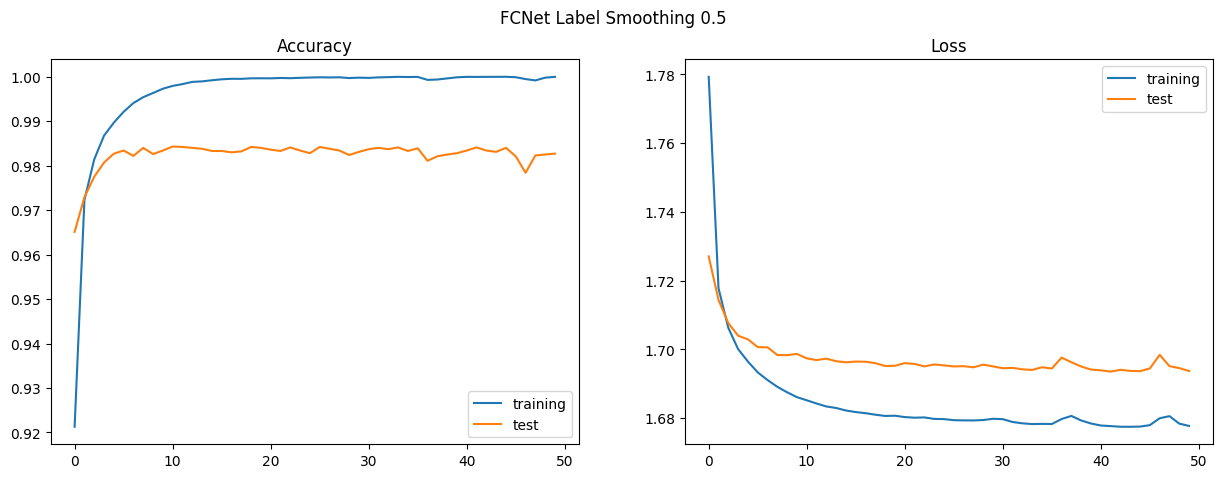

 20612 20260207 02:46:43 FCNet LS 0.5  Clean: 98.27, FGSM: 72.41, PGD: 33.30, CW: 26.33
 20612 20260207 02:46:44 FCNet 模型参数大小为：266610


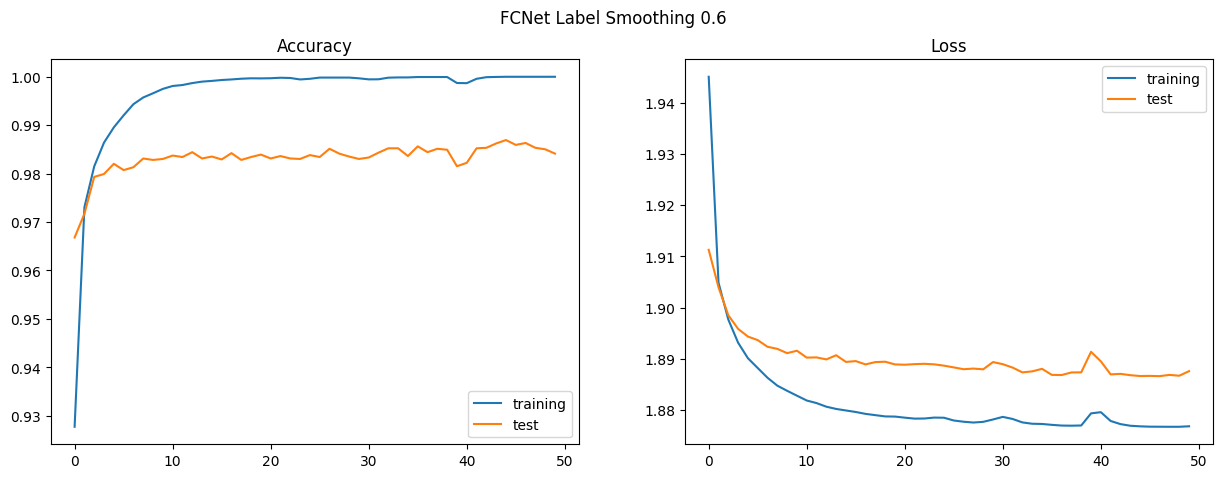

 20612 20260207 02:55:05 FCNet LS 0.6  Clean: 98.41, FGSM: 76.75, PGD: 55.05, CW: 45.45
 20612 20260207 02:55:05 FCNet 模型参数大小为：266610


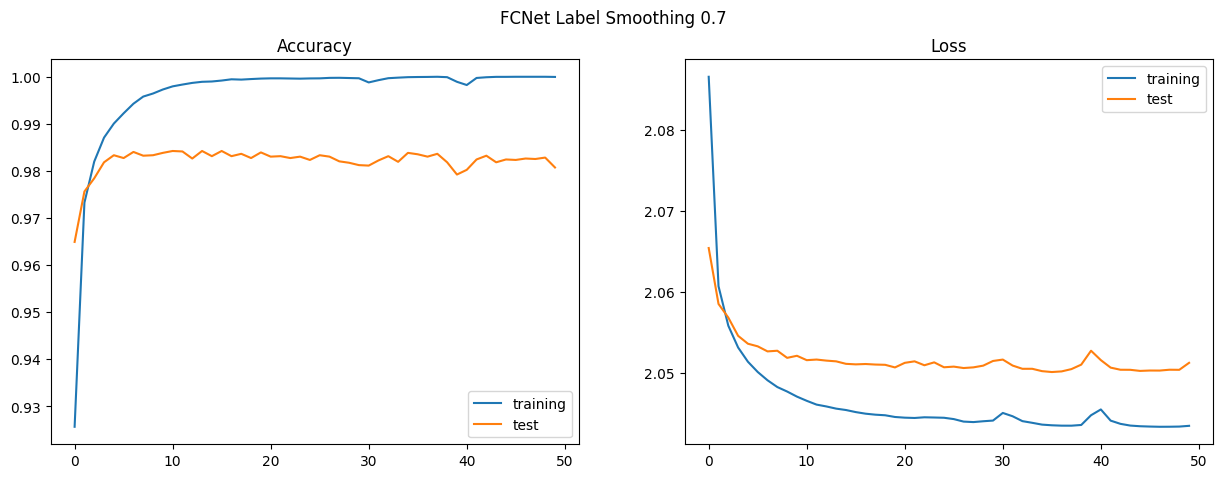

 20612 20260207 03:06:16 FCNet LS 0.7  Clean: 98.07, FGSM: 70.77, PGD: 37.50, CW: 31.14
 20612 20260207 03:06:16 FCNet 模型参数大小为：266610


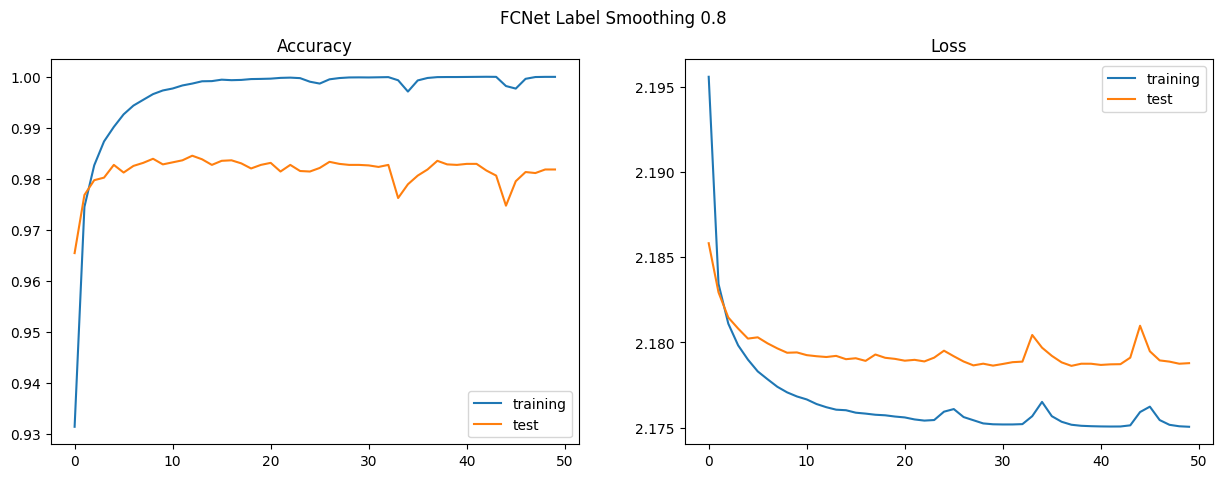

 20612 20260207 03:14:56 FCNet LS 0.8  Clean: 98.18, FGSM: 77.18, PGD: 38.47, CW: 29.40
 20612 20260207 03:14:56 FCNet 模型参数大小为：266610


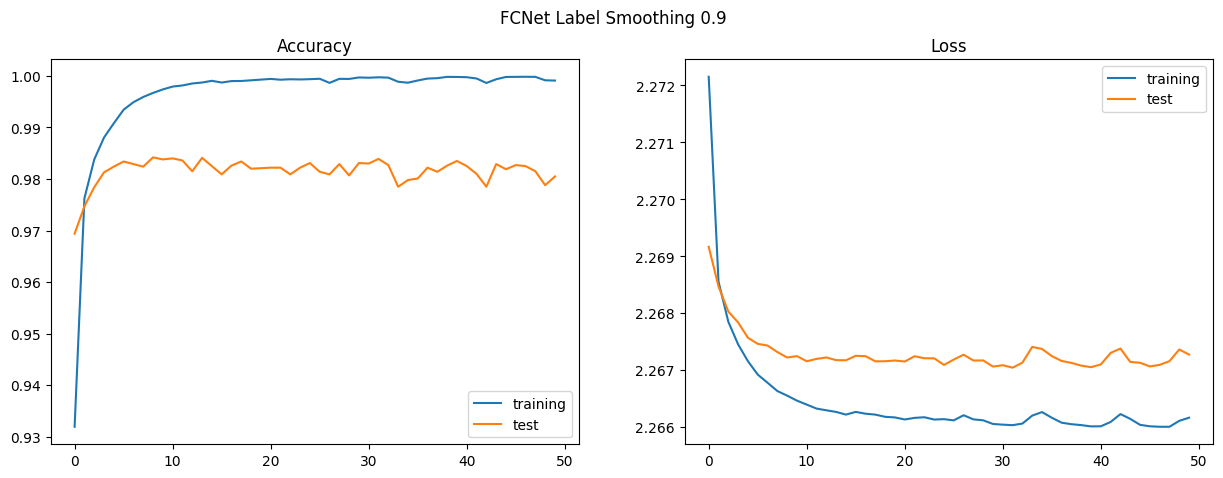

 20612 20260207 03:22:49 FCNet LS 0.9  Clean: 98.05, FGSM: 82.20, PGD: 57.28, CW: 54.29


In [12]:
"""
    测试不同平滑系数Label Smoothing对FCNet防御性能的影响
"""
FCNET_LS_LAMBDA_LIST = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
fcnet_result_dict = {}

for LS_LAMBDA in FCNET_LS_LAMBDA_LIST:
    fcnet_result_dict[LS_LAMBDA] = fcnet_ls_train_eval(LS_LAMBDA)

C:\Users\31198\AppData\Local\Temp\ipykernel_20612\3949963899.py:37: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31198\AppData\Local\Temp\ipykernel_20612\3949963899.py:37: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31198\AppData\Local\Temp\ipykernel_20612\3949963899.py:37: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31198\AppData\Local\Temp\ipykernel_20612\3949963899.py:37: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31198\AppData\Local\Temp\ipykernel_20612\3949963899.py:37: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31198\AppData\Local\Temp\ipykernel_20612\3949963899.py:37: UserWarning: Glyph 30340 (\

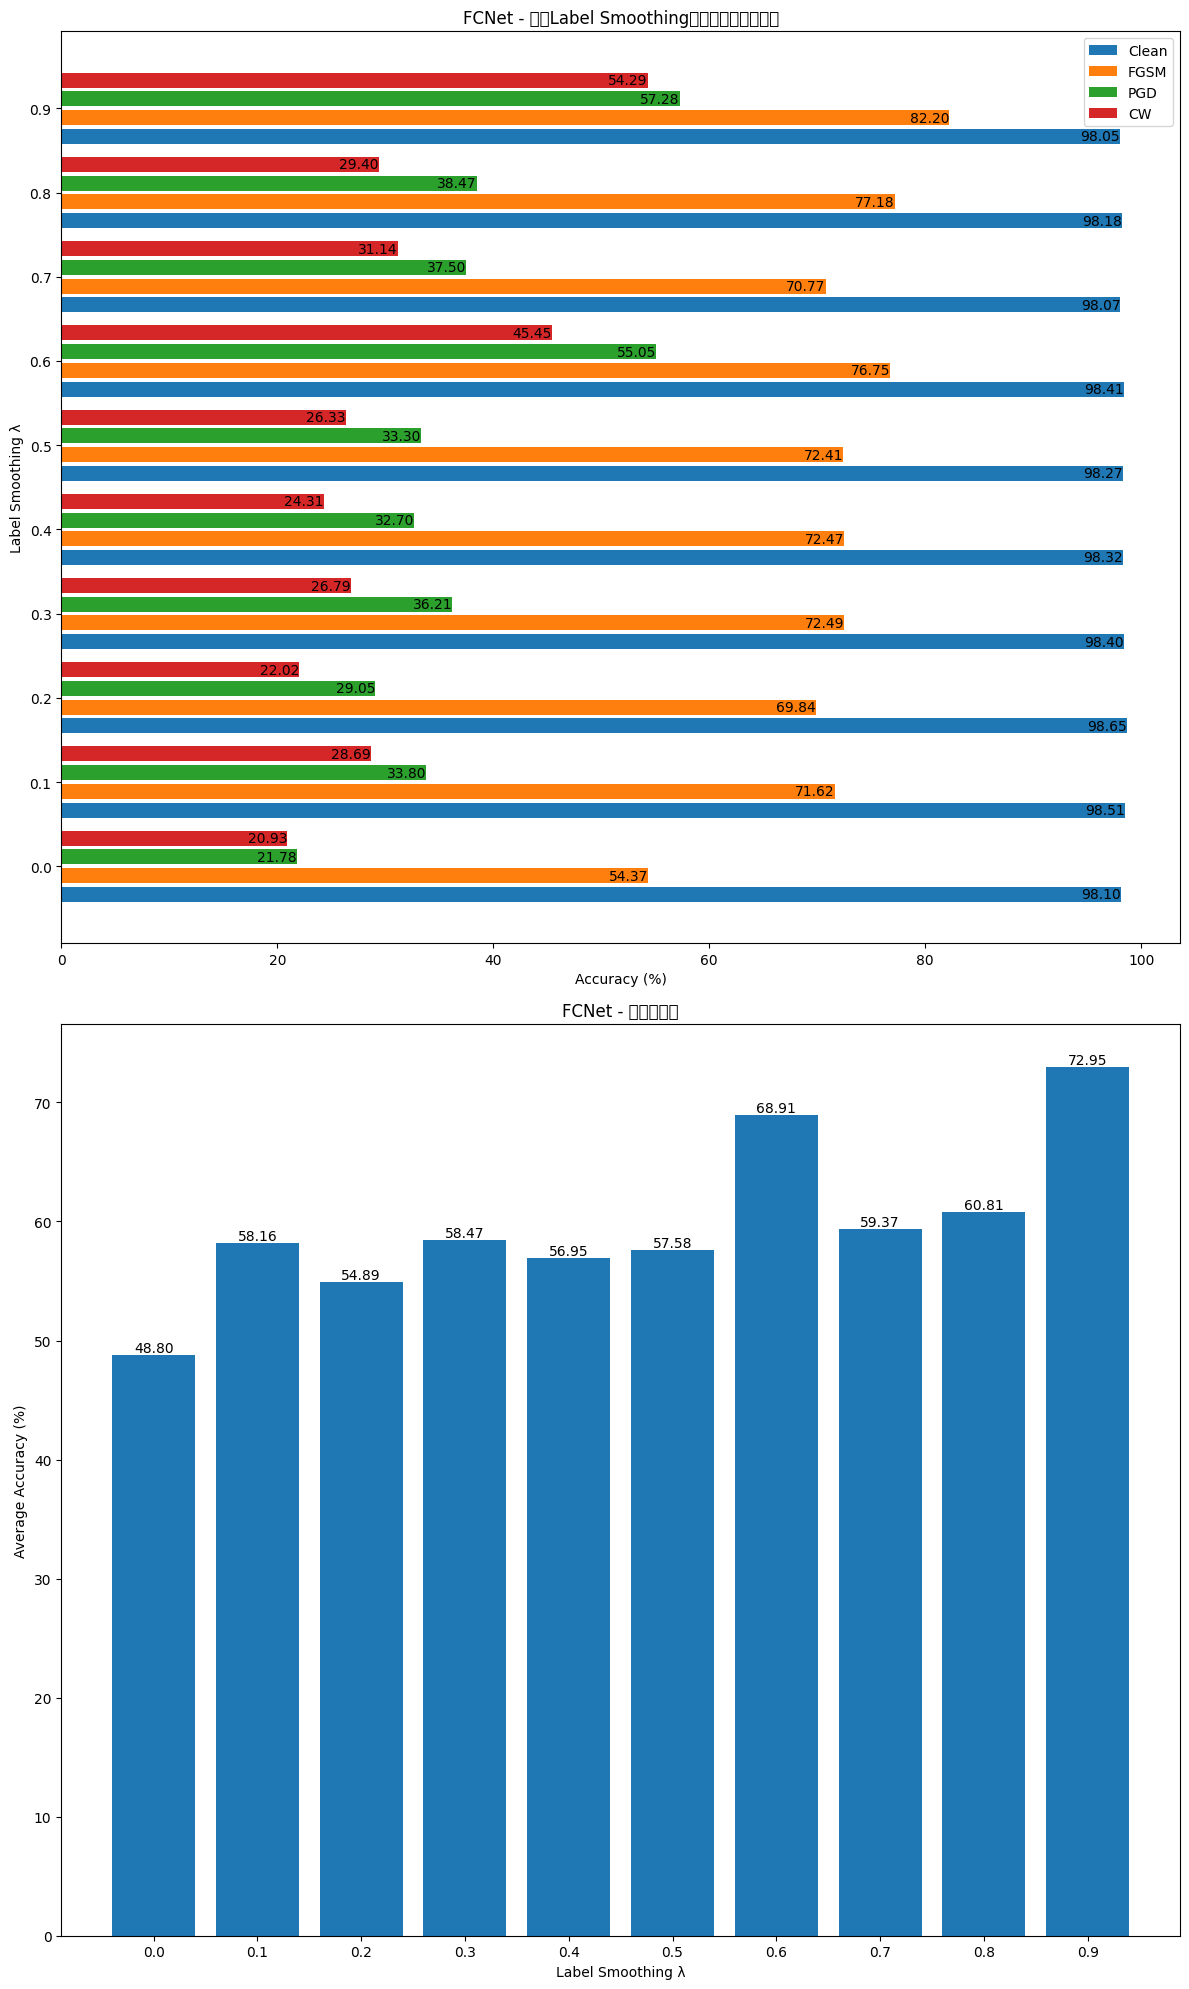


鲁棒性最好的FCNet模型: Label Smoothing λ = 0.9
平均准确率: 72.95%
Clean: 98.05%, FGSM: 82.20%, PGD: 57.28%, CW: 54.29%


In [13]:
"""
    绘制FCNet不同Label Smoothing参数的性能对比图，并选出鲁棒性最好的模型
"""
import numpy as np

fcnet_ls_lambda_list = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
idx = 4.5 * np.arange(len(fcnet_ls_lambda_list))
item_list = ['Clean', 'FGSM', 'PGD', 'CW']

# 绘制条形图，对比不同Label Smoothing参数训练的FCNet模型的性能
plt.figure(figsize=(12, 20))

plt.subplot(2, 1, 1)
for i, item in enumerate(item_list):
    acc_list = [fcnet_result_dict[k][i] for k in fcnet_ls_lambda_list]
    plt.barh(idx + i, acc_list, label=item)

    for j, acc in zip(idx, acc_list):
        plt.text(acc, j + i, f'{acc:.2f}', ha='right', va='center')

plt.legend()
plt.yticks(idx + 1.5, fcnet_ls_lambda_list)
plt.ylabel('Label Smoothing λ')
plt.xlabel('Accuracy (%)')
plt.title('FCNet - 不同Label Smoothing参数下的鲁棒性对比')

plt.subplot(2, 1, 2)
idx = np.arange(len(fcnet_ls_lambda_list))
mean_acc_list = [sum(fcnet_result_dict[k]) / len(fcnet_result_dict[k]) for k in fcnet_ls_lambda_list]
plt.bar(idx, mean_acc_list)
for i, acc in enumerate(mean_acc_list):
    plt.text(i, acc, f'{acc:.2f}', ha='center', va='bottom')
plt.xticks(idx, fcnet_ls_lambda_list)
plt.xlabel('Label Smoothing λ')
plt.ylabel('Average Accuracy (%)')
plt.title('FCNet - 平均准确率')
plt.tight_layout()
plt.show()

# 选出鲁棒性最好的模型
best_lambda = max(fcnet_ls_lambda_list, key=lambda k: sum(fcnet_result_dict[k]) / len(fcnet_result_dict[k]))
best_mean_acc = sum(fcnet_result_dict[best_lambda]) / len(fcnet_result_dict[best_lambda])
print(f'\n鲁棒性最好的FCNet模型: Label Smoothing λ = {best_lambda}')
print(f'平均准确率: {best_mean_acc:.2f}%')
print(f'Clean: {fcnet_result_dict[best_lambda][0]:.2f}%, FGSM: {fcnet_result_dict[best_lambda][1]:.2f}%, '
      f'PGD: {fcnet_result_dict[best_lambda][2]:.2f}%, CW: {fcnet_result_dict[best_lambda][3]:.2f}%')

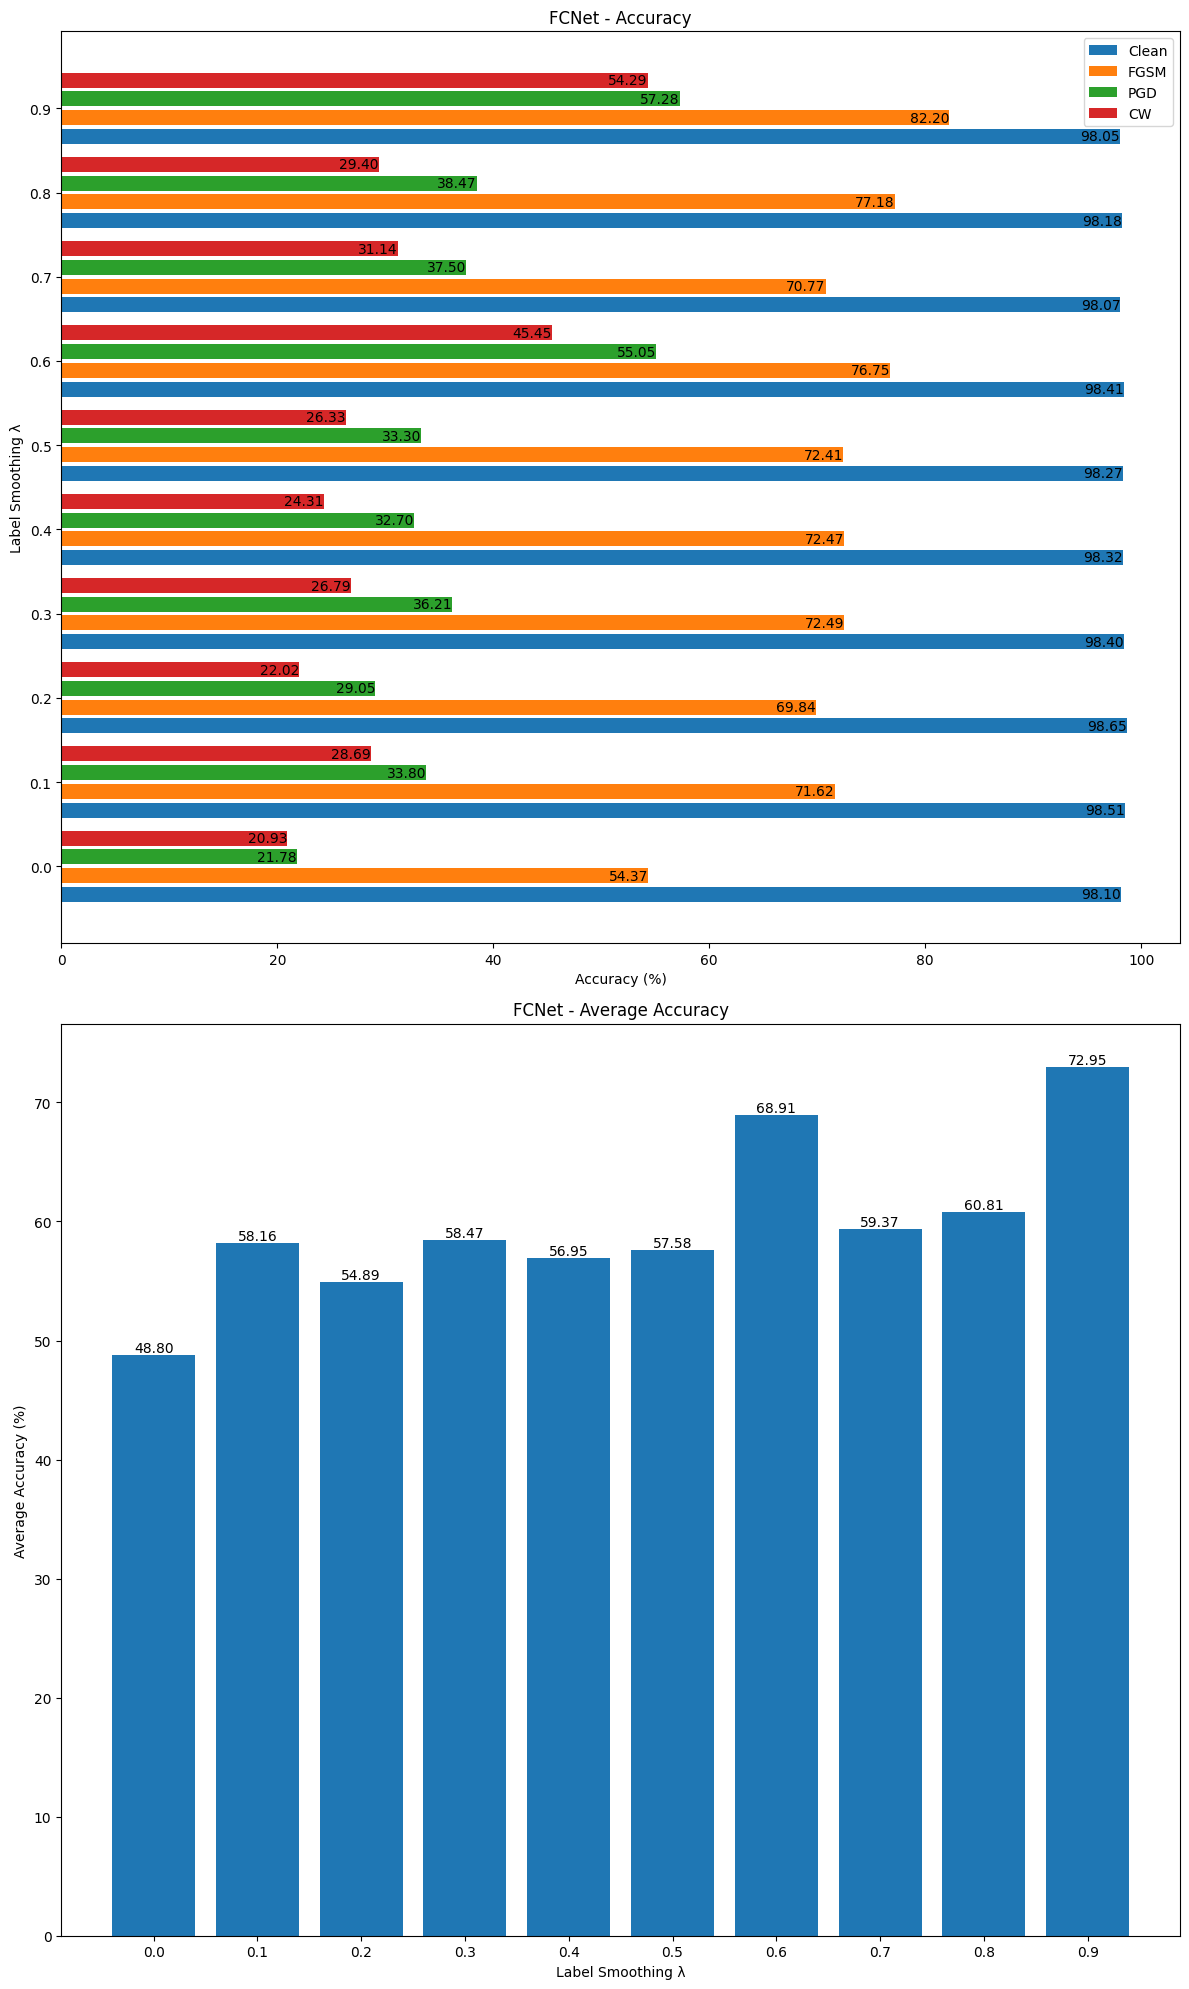


鲁棒性最好的FCNet模型: Label Smoothing λ = 0.9
平均准确率: 72.95%
Clean: 98.05%, FGSM: 82.20%, PGD: 57.28%, CW: 54.29%


In [14]:
"""
    绘制FCNet不同Label Smoothing参数的性能对比图，并选出鲁棒性最好的模型
"""
import numpy as np

fcnet_ls_lambda_list = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
idx = 4.5 * np.arange(len(fcnet_ls_lambda_list))
item_list = ['Clean', 'FGSM', 'PGD', 'CW']

# 绘制条形图，对比不同Label Smoothing参数训练的FCNet模型的性能
plt.figure(figsize=(12, 20))

plt.subplot(2, 1, 1)
for i, item in enumerate(item_list):
    acc_list = [fcnet_result_dict[k][i] for k in fcnet_ls_lambda_list]
    plt.barh(idx + i, acc_list, label=item)

    for j, acc in zip(idx, acc_list):
        plt.text(acc, j + i, f'{acc:.2f}', ha='right', va='center')

plt.legend()
plt.yticks(idx + 1.5, fcnet_ls_lambda_list)
plt.ylabel('Label Smoothing λ')
plt.xlabel('Accuracy (%)')
plt.title('FCNet - Accuracy')

plt.subplot(2, 1, 2)
idx = np.arange(len(fcnet_ls_lambda_list))
mean_acc_list = [sum(fcnet_result_dict[k]) / len(fcnet_result_dict[k]) for k in fcnet_ls_lambda_list]
plt.bar(idx, mean_acc_list)
for i, acc in enumerate(mean_acc_list):
    plt.text(i, acc, f'{acc:.2f}', ha='center', va='bottom')
plt.xticks(idx, fcnet_ls_lambda_list)
plt.xlabel('Label Smoothing λ')
plt.ylabel('Average Accuracy (%)')
plt.title('FCNet - Average Accuracy')
plt.tight_layout()
plt.show()

# 选出鲁棒性最好的模型
best_lambda = max(fcnet_ls_lambda_list, key=lambda k: sum(fcnet_result_dict[k]) / len(fcnet_result_dict[k]))
best_mean_acc = sum(fcnet_result_dict[best_lambda]) / len(fcnet_result_dict[best_lambda])
print(f'\n鲁棒性最好的FCNet模型: Label Smoothing λ = {best_lambda}')
print(f'平均准确率: {best_mean_acc:.2f}%')
print(f'Clean: {fcnet_result_dict[best_lambda][0]:.2f}%, FGSM: {fcnet_result_dict[best_lambda][1]:.2f}%, '
      f'PGD: {fcnet_result_dict[best_lambda][2]:.2f}%, CW: {fcnet_result_dict[best_lambda][3]:.2f}%')